# TRAPPIST-1b — N₂ / CH₄ grid analysis

This notebook processes the logL grid computed by `grid_retrieval.py`
and produces two publication-quality figures:

1. **N₂ vs CH₄** — 2D posterior map with 1σ / 2σ / 3σ contours and marginal distributions
2. **H₂ vs CH₄** — same figure, but replacing N₂ with the *actual* H₂ abundance used by the model

The H₂ abundance is a derived quantity: since N₂ occupies part of the atmosphere,
H₂ is reduced accordingly.  Specifically:
$$\mathrm{H_2} = 0.85 \times (1 - X_{\mathrm{N_2}} - X_{\mathrm{CH_4}})$$
where the 0.85 factor reflects the H₂ : He background ratio (`vmrh2he = [0.85, 0.15]`).
This formula is valid here because the TP profile is isothermal and dissociation is off,
so abundances are constant with pressure (any pressure level gives the same result).

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import griddata

## 2. Configuration

In [22]:
# Path to the grid file — adjust if the notebook is not in the same directory
directory = '/home/mathisb/scratch/HRS_retrievals/grid_retrievals/'
DATA_FILE = Path(directory + 'd_N2_H2O_4n.npz')

# H2 / He ratio in the background gas (from vmrh2he in retrieval)
VMR_H2_FRAC = 0.85

# Sigma contour levels to draw on the 2D maps
SIGMA_LEVELS = [1, 2, 3]

# Colormap for the 2D posterior maps
COLORMAP = 'plasma'

# Output figure filenames (set to None to skip saving)
# SAVE_N2_CH4 = 'map_N2_CH4.pdf'
# SAVE_H2_CH4 = 'map_H2_CH4.pdf'
SAVE_N2_CH4 = None
SAVE_H2_CH4 = None

## 3. Load and inspect the grid data

In [23]:
data = np.load(DATA_FILE)

# Metadata
param1_name = str(data['param1_name'])
param2_name = str(data['param2_name'])

# Input grids
param1_axis = data['param1_input_grid']
param2_axis = data['param2_input_grid']

# Flattened parameter values corresponding to each likelihood evaluation
param1 = data['param1']
param2 = data['param2']

# Log-likelihood map and results table
logl_grid = data['logl_grid']
results = data['results']
logl_flat = results[:,2]

# Number of points in each input parameter grid
N_GRID = len(param1_axis)

# Get param grids
param1_grid, param2_grid = np.meshgrid(param1_axis, param2_axis)


# Sanity check
best_idx = np.argmax(logl_flat)

best_param1 = param1[best_idx]
best_param2 = param2[best_idx]

print(f"Grid shape : {logl_grid.shape}")
print(f"logL range : {logl_flat.min():.3f} → {logl_flat.max():.3f}")
print(f"Best point : log10({param1_name}) = {best_param1:.2f}  "
      f"→  {param1_name} VMR = {10**best_param1:.2}")
print(f"             log10({param2_name}) = {best_param2:.2f}  "
      f"→  {param2_name} VMR = {10**best_param2:.2}")


Grid shape : (100, 100)
logL range : -715038.171 → -714704.258
Best point : log10(N2) = -11.00  →  N2 VMR = 1e-11
             log10(H2O) = -1.58  →  H2O VMR = 0.027


## 4. Helper functions

In [4]:
def normalize_posterior(logl_grid_nx_ny, dx, dy):
    """
    Convert a log-likelihood grid to a normalized 2D posterior.

    The posterior is assumed to be proportional to exp(logL) with a
    flat prior over the grid.  We subtract the maximum before
    exponentiating for numerical stability.

    Parameters
    ----------
    logl_grid_nx_ny : (n_x, n_y) array
        Log-likelihood values; axis 0 = x parameter, axis 1 = y parameter.
    dx, dy : float
        Grid spacing along x and y.

    Returns
    -------
    posterior : (n_x, n_y) array
        Normalized linear posterior (integrates to 1 over the grid).
    """
    # Shift for numerical stability before exponentiating
    log_shifted = logl_grid_nx_ny - logl_grid_nx_ny.max()
    posterior   = np.exp(log_shifted)

    # Normalize using the trapezoidal rule along both axes
    evidence = np.trapz(np.trapz(posterior, dx=dx, axis=1), dx=dy)

    return posterior / evidence


def compute_marginals(posterior_nx_ny, dx, dy):
    """
    Compute 1D marginal distributions from a 2D posterior.

    Parameters
    ----------
    posterior_nx_ny : (n_x, n_y) array
    dx, dy : float — grid spacing along x (axis 0) and y (axis 1)

    Returns
    -------
    marg_x : (n_x,) array — marginal distribution of x (integrated over y)
    marg_y : (n_y,) array — marginal distribution of y (integrated over x)
    """
    # Integrate over y (axis 1, spacing dy) → distribution of x
    marg_x = np.trapz(posterior_nx_ny, dx=dy, axis=1)
    # Integrate over x (axis 0, spacing dx) → distribution of y
    marg_y = np.trapz(posterior_nx_ny, dx=dx, axis=0)

    return marg_x, marg_y


def get_sigma_contour_levels(posterior_nx_ny, dx, dy, sigma_values):
    """
    Find posterior density values corresponding to given sigma levels.

    In 2D, the enclosed probability mass at n-sigma follows the chi²
    distribution with 2 degrees of freedom:
        P(< n-sigma) = 1 - exp(-n² / 2)
    This differs from the 1D Gaussian convention.

    Parameters
    ----------
    posterior_nx_ny : (n_x, n_y) array — normalized posterior
    dx, dy : float — grid spacing
    sigma_values : list of float — sigma levels (e.g. [1, 2, 3])

    Returns
    -------
    levels : (n_sigma,) array — posterior density at each sigma level
    """
    # Convert sigma values to probability masses using the 2D chi² convention
    sigma_masses = 1.0 - np.exp(-0.5 * np.array(sigma_values)**2)

    # Sort posterior values in descending order and compute the cumulative
    # enclosed probability as we add more and more pixels
    post_flat   = posterior_nx_ny.flatten()
    post_sorted = np.sort(post_flat)[::-1]
    csum        = np.cumsum(post_sorted) * dx * dy
    csum       /= csum[-1]   # renormalize to [0, 1]

    # For each target mass, find the corresponding posterior density threshold
    levels = []
    for mass in sigma_masses:
        idx = int(np.sum(csum < mass)) - 1
        idx = np.clip(idx, 0, len(post_sorted) - 1)
        levels.append(post_sorted[idx])

    return np.array(levels)


def plot_abundance_map(x_axis, y_axis, posterior, marg_x, marg_y,
                       x_label, y_label,
                       sigma_levels=None,
                       title=None,
                       figsize=(7, 7)):

    if sigma_levels is None:
        sigma_levels = SIGMA_LEVELS

    dx = x_axis[1] - x_axis[0]
    dy = y_axis[1] - y_axis[0]

    # Transpose for plotting mapping orientation consistency
    post = posterior.T

    idx = np.unravel_index(np.argmax(post), post.shape)
    y_peak = y_axis[idx[0]]
    x_peak = x_axis[idx[1]]

    # Fixed: Ensure consistency with what your contour generator expects
    sigma_lvls = get_sigma_contour_levels(posterior, dx, dy, sigma_levels)
    sigma_labels = {lvl: f'{s}σ' for lvl, s in zip(sigma_lvls, sigma_levels)}

    fig = plt.figure(figsize=figsize)

    gs = gridspec.GridSpec(
        2, 2,
        width_ratios=[4, 1],
        height_ratios=[4, 1],
        hspace=0.05,
        wspace=0.05,
    )

    ax_map = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1])
    ax_bottom = fig.add_subplot(gs[1, 0])
    fig.add_subplot(gs[1, 1]).axis('off')

    # Main heatmap
    img = ax_map.pcolormesh(
        x_axis, y_axis,
        np.log10(post + 1e-300),
        cmap=COLORMAP,
        shading='auto',
    )

    # Contours
    cs = ax_map.contour(
        x_axis, y_axis,
        post,
        levels=sigma_lvls[::-1],
        colors='white',
        linewidths=1.5,
    )
    ax_map.clabel(cs, fmt=sigma_labels, fontsize=10)

    # Peak marker
    ax_map.plot(x_peak, y_peak, 'r+', ms=14, mew=2.5, label=f'Max: ({x_peak:.1f}, {y_peak:.1f})')
    ax_map.legend(fontsize=9, framealpha=0.7)

    ax_map.set_ylabel(y_label)
    ax_map.tick_params(direction='in', top=True, right=True, labelbottom=False)

    # Colorbar (This squishes ax_map slightly)
    cbar = fig.colorbar(img, ax=ax_map, location='top', fraction=0.046, pad=0.04)
    cbar.set_label(r'$\log_{10}$(posterior)')

    # Force the layout update so we can fetch accurate squished coordinates
    fig.canvas.draw() 
    
    # FIX 1: Align right panel height perfectly with the squished main map
    pos_map = ax_map.get_position()
    pos_right = ax_right.get_position()
    ax_right.set_position([pos_right.x0, pos_map.y0, pos_right.width, pos_map.height])

    # Right Panel Plotting
    ax_right.plot(marg_y, y_axis, color='steelblue')
    ax_right.fill_betweenx(y_axis, 0, marg_y, alpha=0.3)
    ax_right.axhline(y_peak, color='tomato', ls='--', lw=0.9)

    ax_right.set_xlabel('P')
    ax_right.set_xlim(left=0)
    ax_right.set_ylabel('')
    ax_right.set_ylim(ax_map.get_ylim())
    
    # FIX 3: Internal tick marks for the right panel (sharing y-axis properties)
    ax_right.set_yticks(ax_map.get_yticks()) 
    ax_right.tick_params(direction='in', left=True, right=True, labelleft=False)

    # Bottom Panel Plotting
    ax_bottom.plot(x_axis, marg_x, color='steelblue')
    ax_bottom.fill_between(x_axis, 0, marg_x, alpha=0.3)
    ax_bottom.axvline(x_peak, color='tomato', ls='--', lw=0.9)

    ax_bottom.set_xlabel(x_label)
    ax_bottom.set_ylabel('P')
    ax_bottom.set_xlim(ax_map.get_xlim())
    
    # FIX 2: Bring back bottom panel Y-ticks but keep them clean inside
    ax_bottom.tick_params(direction='in', top=True, right=True) 

    if title:
        fig.suptitle(title, y=1.01)

    return fig, (ax_map, ax_right, ax_bottom)

## 5. Figure 1 — N₂ vs CH₄ posterior map

We use `posterior[i_n2, i_ch4]`, following the convention of `plot_posterior_2d`
where axis 0 corresponds to the x (horizontal) parameter.

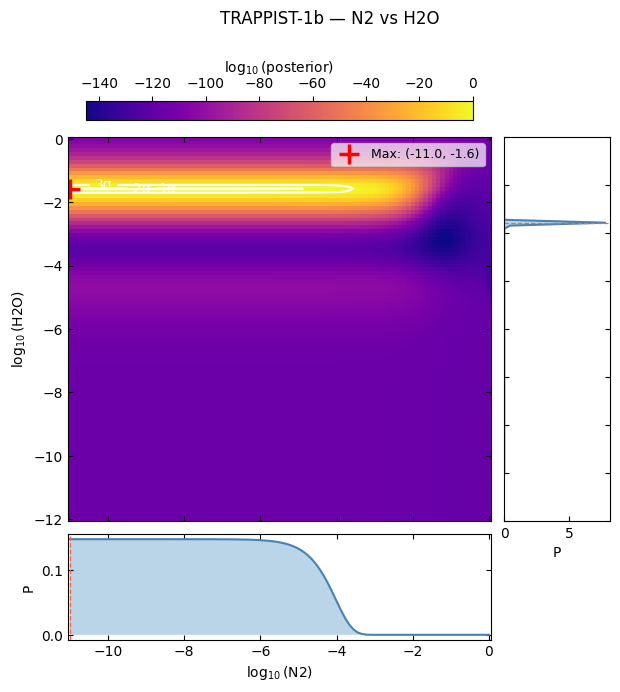

In [24]:
# Spacing in each parameter axis (log10 space)
dx = param1_axis[1] - param1_axis[0]
dy = param2_axis[1] - param2_axis[0]

# logl_grid has shape (param2, param1) = (n2_axis, n1_axis)
# We transpose so that:
# axis 0 → param1 (x-axis)
# axis 1 → param2 (y-axis)
logl_param1_param2 = logl_grid.T

# Normalize posterior
posterior_param1_param2 = normalize_posterior(logl_param1_param2, dx, dy)

# Marginals
marg_param1, marg_param2 = compute_marginals(posterior_param1_param2, dx, dy)

# Plot
fig1, axes1 = plot_abundance_map(
    x_axis=param1_axis,
    y_axis=param2_axis,
    posterior=posterior_param1_param2,
    marg_x=marg_param1,
    marg_y=marg_param2,
    x_label=rf'$\log_{{10}}$({param1_name})',
    y_label=rf'$\log_{{10}}$({param2_name})',
    title=f'TRAPPIST-1b — {param1_name} vs {param2_name}',
)

if SAVE_N2_CH4:
    fig1.savefig(SAVE_N2_CH4, bbox_inches='tight')
    print(f'Saved: {SAVE_N2_CH4}')

plt.show()

## 6. Compute the actual H₂ abundance for each grid point

When N₂ is added to the atmosphere, `gen_abundances` computes the H₂ VMR as:
$$X_{\mathrm{H_2}} = 0.85 \times (1 - X_{\mathrm{N_2}} - X_{\mathrm{CH_4}})$$

Grid points where N₂ + CH₄ > 1 are unphysical (H₂ would be negative).
These correspond to the top-right corner of the N₂–CH₄ grid and are masked below.

/tmp/ipykernel_2205025/3890962453.py:139: UserWarning: No contour levels were found within the data range.
  cs = ax_map.contour(


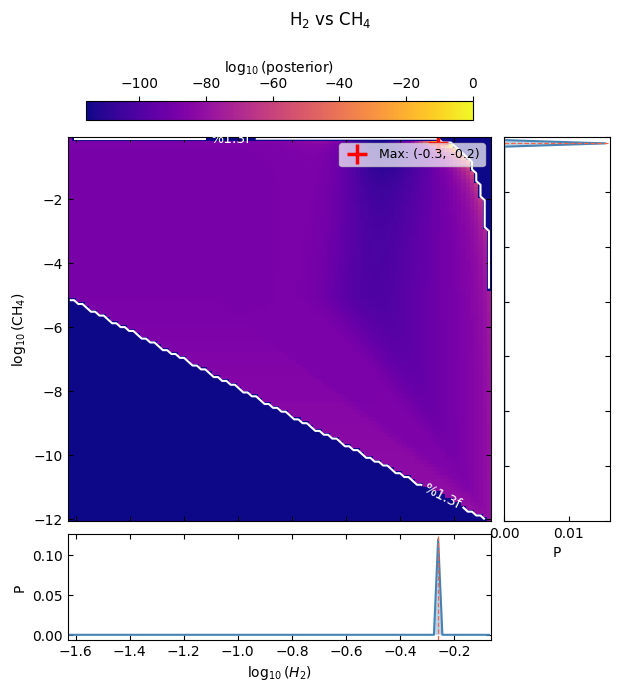

In [25]:
from scipy.interpolate import griddata

# --- Derived quantities ---
param1_vmr = 10**results[:, 0]
param2_vmr = 10**results[:, 1]

h2_vmr = VMR_H2_FRAC * (1.0 - param1_vmr - param2_vmr)

valid_h2 = h2_vmr > 0

log_h2 = np.full_like(h2_vmr, np.nan, dtype=float)
log_h2[valid_h2] = np.log10(h2_vmr[valid_h2])

log_ch4 = results[:, 1]
logl = results[:, 2]

valid = valid_h2 & np.isfinite(log_ch4) & np.isfinite(logl)

log_h2 = log_h2[valid]
log_ch4 = log_ch4[valid]
logl = logl[valid]

# --- Grid ---
N_GRID = int(np.sqrt(len(results)))

h2_axis = np.linspace(np.nanmin(log_h2), np.nanmax(log_h2), N_GRID)
ch4_axis = np.linspace(np.nanmin(log_ch4), np.nanmax(log_ch4), N_GRID)

H2_mesh, CH4_mesh = np.meshgrid(h2_axis, ch4_axis)

source_xy = np.column_stack([log_h2, log_ch4])
target_xy = np.column_stack([H2_mesh.ravel(), CH4_mesh.ravel()])

logl_h2_grid = griddata(
    source_xy,
    logl,
    target_xy,
    method='linear',
    fill_value=np.nanmin(logl),
).reshape(N_GRID, N_GRID)

# --- posterior ---
posterior = np.exp(logl_h2_grid - np.nanmax(logl_h2_grid))
posterior /= np.nansum(posterior)

# --- marginals (FIX for your function) ---
dx = h2_axis[1] - h2_axis[0]
dy = ch4_axis[1] - ch4_axis[0]

marg_h2 = np.nansum(posterior, axis=1) * dy
marg_ch4 = np.nansum(posterior, axis=0) * dx

# --- plot ---
fig, axes = plot_abundance_map(
    x_axis=h2_axis,
    y_axis=ch4_axis,
    posterior=posterior,
    marg_x=marg_h2,
    marg_y=marg_ch4,
    x_label=r'$\log_{10}(H_2)$',
    y_label=r'$\log_{10}$(CH$_4$)',
    title='H$_2$ vs CH$_4$'
)

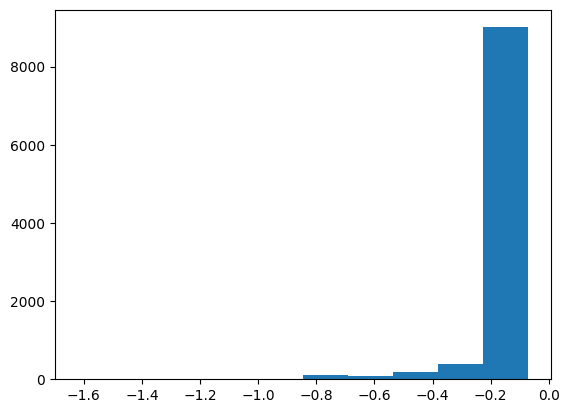

In [26]:
plt.hist(log_h2)
plt.show()

In [7]:
# Convert log-abundance grids to linear VMRs
param1_vmr = 10**param1_grid
param2_vmr = 10**param2_grid

# Compute H2 VMR used by the model
h2_vmr = VMR_H2_FRAC * (1.0 - param1_vmr - param2_vmr)

# Mask unphysical points where H2 would be negative
valid_mask = h2_vmr > 0
n_invalid = np.sum(~valid_mask)

print(f"Unphysical grid points (param1 + param2 > 1): {n_invalid} / {h2_vmr.size}")

# Safe log H2
with np.errstate(invalid='ignore'):
    log_h2_grid = np.where(valid_mask, np.log10(h2_vmr), np.nan)


# Sanity check
best_idx = np.argmax(logl_flat)
i2, i1 = np.unravel_index(best_idx, logl_grid.shape)
h2_best = h2_vmr[i2, i1]

print("\nAt the best-fit point:")
print(f"  log10({param1_name}) = {param1_axis[i1]:.1f}   →  {param1_name} VMR = {10**param1_axis[i1]:.2}")
print(f"  log10({param2_name}) = {param2_axis[i2]:.1f}   →  {param2_name} VMR = {10**param2_axis[i2]:.2}")
print(f"  H2 VMR     = {h2_best:.3}  →  log10(H2) = {np.log10(h2_best):.2f}")

Unphysical grid points (param1 + param2 > 1): 211 / 10000

At the best-fit point:
  log10(N2) = -11.0   →  N2 VMR = 1e-11
  log10(CH4) = -12.0   →  CH4 VMR = 1e-12
  H2 VMR     = 0.85  →  log10(H2) = -0.07


In [8]:
# Build 1D posterior for H2
log_h2_flat = log_h2_grid.ravel()
logl_flat = results[:, 2]

valid = np.isfinite(log_h2_flat) & np.isfinite(logl_flat)

log_h2_flat = log_h2_flat[valid]
logl_flat = logl_flat[valid]


# Convert logl --> posterior weights
weights = np.exp(logl_flat - np.max(logl_flat))  # numerical stability
weights /= np.sum(weights)


# Build H2 posterior
h2_axis = np.linspace(log_h2_flat.min(), log_h2_flat.max(), 300)

posterior_h2, edges = np.histogram(
    log_h2_flat,
    bins=h2_axis,
    weights=weights,
    density=True
)

h2_centers = 0.5 * (edges[:-1] + edges[1:])


# Get cumulative distribution
cdf = np.cumsum(posterior_h2)
cdf /= cdf[-1]


# 3 sig upper limit
h2_low = h2_centers[np.searchsorted(cdf, 0.0027)]
h2_high = h2_centers[np.searchsorted(cdf, 0.9973)]

print(f"3σ upper limit on H2:")
print(f"  log10(H2) < {h2_3sigma:.2f}")
print(f"  H2 < {10**h2_3sigma:.2e}")


# Plot
plt.figure(figsize=(6,4))

plt.plot(h2_centers, posterior_h2, color='steelblue', lw=2)

plt.axvline(h2_low, color='tomato', ls='--', lw=1.5)
plt.axvline(h2_high, color='tomato', ls='--', lw=1.5)

plt.xlabel(r'$\log_{10}(H_2)$')
plt.ylabel('Posterior density')

plt.title('H$_2$ posterior with 3σ limits')

plt.show()

3σ upper limit on H2:


NameError: name 'h2_3sigma' is not defined

## 7. Figure 2 — H₂ vs CH₄ posterior map

The original grid is regular in (N₂, CH₄) space, but irregular in (H₂, CH₄) space
because H₂ depends on both N₂ and CH₄.  We interpolate the logL onto a regular
(H₂, CH₄) grid before normalizing and plotting.

In [9]:
# Build a regular log10(H2) axis.
# H2_max ≈ 0.85 * (1 - 0 - 0) = 0.85  when N2 and CH4 are negligible.
# H2_min → 0 when N2 → 1.  We use the same log range as N2 for consistency.
h2_max_log = np.log10(VMR_H2_FRAC)   # ≈ -0.07
h2_axis    = np.linspace(-12, h2_max_log, N_GRID)

# Flatten the valid grid points to scatter-point format: (log_H2, log_CH4) → logL
valid_flat  = valid_mask.ravel()
log_h2_flat = log_h2_grid.ravel()

source_xy  = np.column_stack([
    log_h2_flat[valid_flat],    # H2 coordinate
    log_ch4_flat[valid_flat],   # CH4 coordinate
])
source_logl = logl_flat[valid_flat]

# Build the target regular grid in (H2, CH4) space
H2_mesh, CH4_mesh = np.meshgrid(h2_axis, ch4_axis)   # (n_ch4, n_h2)
target_xy = np.column_stack([H2_mesh.ravel(), CH4_mesh.ravel()])

# Interpolate logL onto the regular (H2, CH4) grid
# Points outside the convex hull of the source data get the minimum logL value
logl_h2_flat = griddata(
    source_xy, source_logl, target_xy,
    method='linear',
    fill_value=source_logl.min(),
)
# logl_h2_grid[i_ch4, i_h2]
logl_h2_grid = logl_h2_flat.reshape(N_GRID, N_GRID)

print("Interpolated logL grid: done")
print(f"  shape : {logl_h2_grid.shape}")
print(f"  H2 axis: {h2_axis[0]:.2f} → {h2_axis[-1]:.2f}  (log10 VMR)")

# Build a regular log10(H2) axis
h2_max_log = np.log10(VMR_H2_FRAC)
h2_axis = np.linspace(-12, h2_max_log, N_GRID)

# Flatten valid grid points
valid_flat = valid_mask.ravel()
log_h2_flat = log_h2_grid.ravel()
log_p2_flat = param2_grid.ravel()

source_xy = np.column_stack([
    log_h2_flat[valid_flat],
    log_p2_flat[valid_flat],
])

source_logl = logl_flat[valid_flat]

# Target regular grid in (H2, param2) space
H2_mesh, P2_mesh = np.meshgrid(h2_axis, param2_axis)
target_xy = np.column_stack([H2_mesh.ravel(), P2_mesh.ravel()])

# Interpolate logL onto (H2, param2)
logl_h2_flat = griddata(
    source_xy, source_logl, target_xy,
    method='linear',
    fill_value=source_logl.min(),
)

logl_h2_grid = logl_h2_flat.reshape(N_GRID, N_GRID)

print("Interpolated logL grid: done")
print(f"  shape : {logl_h2_grid.shape}")
print(f"  H2 axis: {h2_axis[0]:.2f} → {h2_axis[-1]:.2f}  (log10 VMR)")

NameError: name 'log_ch4_flat' is not defined

/tmp/ipykernel_2141804/3775782376.py:139: UserWarning: No contour levels were found within the data range.
  cs = ax_map.contour(


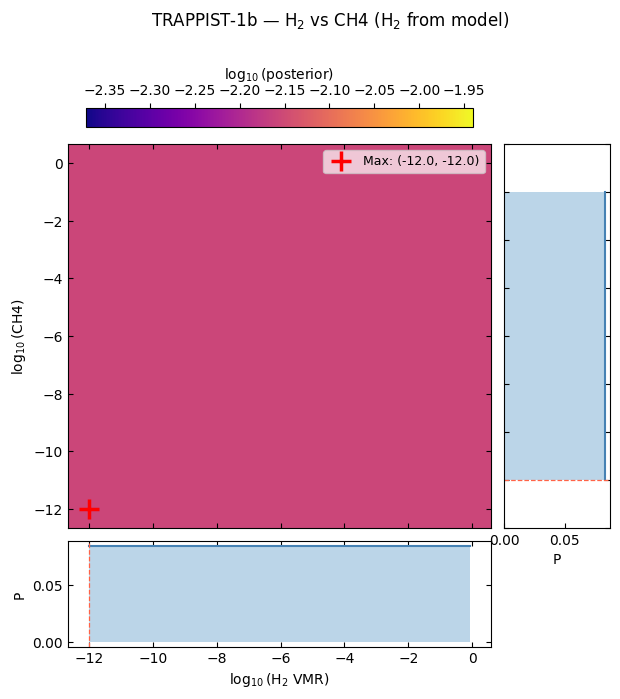

In [57]:
# Spacing of the H2 axis
dx_h2 = h2_axis[1] - h2_axis[0]
dy = param2_axis[1] - param2_axis[0]

# logl_h2_grid is (n_ch4, n_h2) → transpose to (n_h2, n_ch4)
logl_h2_h2param2 = logl_h2_grid.T

posterior_h2_h2param2 = normalize_posterior(logl_h2_h2param2, dx_h2, dy)

marg_h2, marg_param2 = compute_marginals(posterior_h2_h2param2, dx_h2, dy)

fig2, axes2 = plot_abundance_map(
    x_axis=h2_axis,
    y_axis=param2_axis,
    posterior=posterior_h2_h2param2,
    marg_x=marg_h2,
    marg_y=marg_param2,
    x_label=r'$\log_{10}$(H$_2$ VMR)',
    y_label=rf'$\log_{{10}}$({param2_name})',
    title=f'TRAPPIST-1b — H$_2$ vs {param2_name} (H$_2$ from model)',
)

if SAVE_H2_CH4:
    fig2.savefig(SAVE_H2_CH4, bbox_inches='tight')
    print(f'Saved: {SAVE_H2_CH4}')

plt.show()